# ICS 2405: Knowledge-Based Systmes

### k-Nearest Neighbors:
we look at the nerest neigbors ie features of examples that have similarites; this is the nearest neighbors algorithm

similarity can be thought of as distance and is computed using `euclidean`, `minkowski` and `hamming` distances

### model:
working on a 3-nn model; the 3 in k-NN is not a fixed ie a **hyperparameter** - not to be tuned as something that affects the training process ; it is a parameter for the model - ie setting it from the jump gives you a different machine/model.

### the `iris` dataset

the `iris` dataset has a long history  of  having been a part of machine learning and statistics

>INFO: from the work of **sir ronald fisher**, a mid-20th century statistician
>
>kinds of classification: binary, multiclass



### what is it?:
what is the iris data? each row describes one iris—that’s a flower, by the
way—in terms of the length and width of that flower’s sepals and petals.  
target: the particular species—one of three—of that iris: `setosa`, `versicolor`, or `virginica`.

In [1]:
# import numpy as np 
import pandas as pd
# import needed for 'projection':'3d'
# from mpl_toolkits.mplot3d import Axes3D
# from mlwpy import * 
from sklearn import datasets

from sklearn import (datasets, metrics, model_selection as skms, naive_bayes, neighbors)
import seaborn as sns
# %matplotlib inline

In [2]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

iris_df['target'] = iris.target
pd.concat([iris_df.head(5), iris_df.tail(5)])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


# plot of some of the dataset


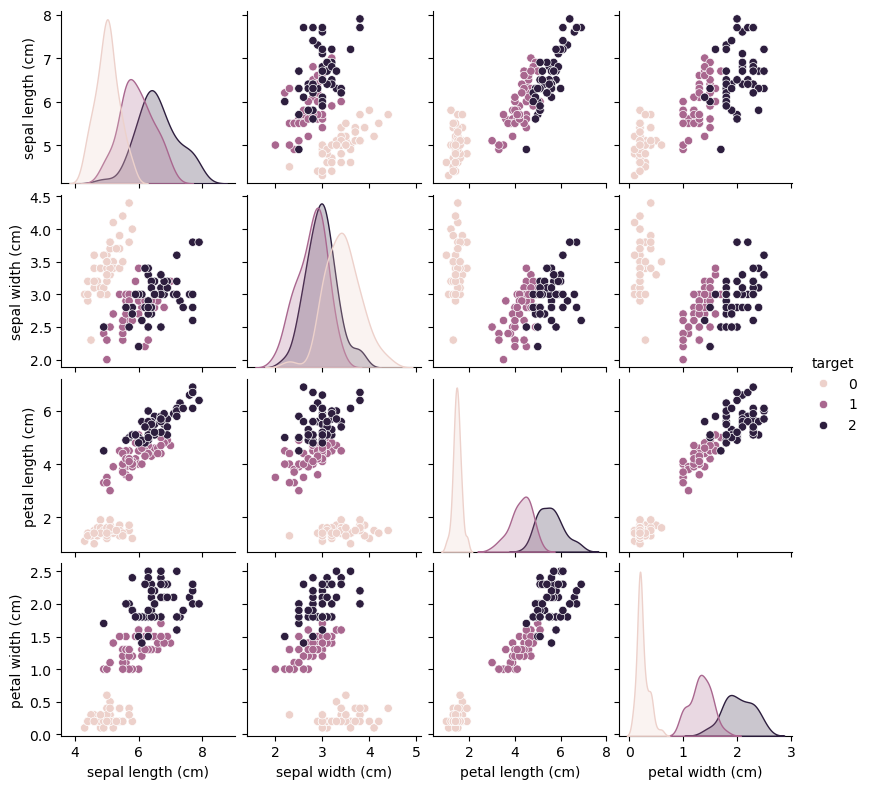

In [3]:
sns.pairplot(iris_df, hue='target', height=2.0)

## classses out:

In [4]:
print('targets: {}'.format(iris.target_names), iris.target_names[0], sep="\n")

targets: ['setosa' 'versicolor' 'virginica']
setosa


### model: training + testing:
to begin with, we want to gauge how our model generalizes to unseen examples/data.  
the dataset is made up of featurs and targets we split the dataset into:
 1. features: training and testing features
 2. targets: training and testing targets

`sklearn]`: we will use the `train_test_split` function to segement our dataset. this is as similar in `tensorflow`, and `pytorch`



In [5]:
# simple train-test split
(iris_train_ftrs, iris_test_ftrs, iris_train_tgt, iris_test_tgt) = skms.train_test_split(iris.data, iris.target, test_size=.25)
print("Train features shape:", iris_train_ftrs.shape)
print("Test features shape:", iris_test_ftrs.shape)

Train features shape: (112, 4)
Test features shape: (38, 4)


#### 3-NN

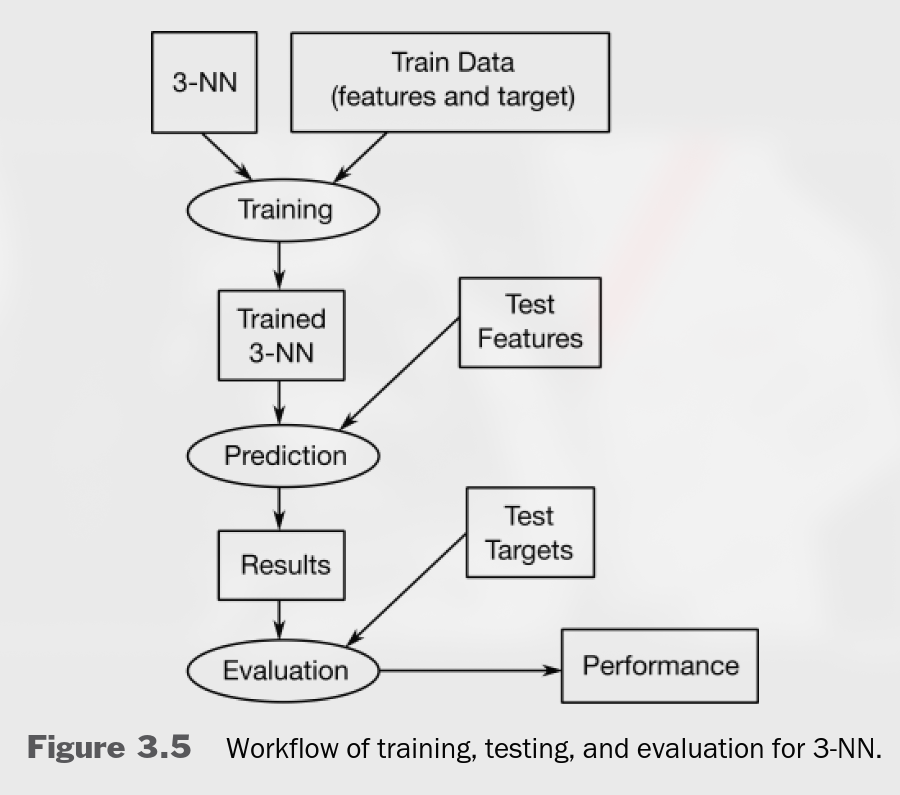

In [6]:
from IPython.display import Image
image_path = './knn.png'
Image(filename=image_path)

In [7]:
# stand-alone code
from sklearn import (datasets, metrics, model_selection as skms, naive_bayes, neighbors)
# we set random_state so the results are reproducible
# otherwise, we get different training and testing sets

iris = datasets.load_iris()
(iris_train_ftrs, iris_test_ftrs, iris_train_tgt, iris_test_tgt) = skms.train_test_split(iris.data,
                                                                                         iris.target, 
                                                                                         test_size=.20,
                                                                                         random_state=42)

knn = neighbors.KNeighborsClassifier(n_neighbors=3) # default n_neighbors=5
fit = knn.fit(iris_train_ftrs, iris_train_tgt)

predict = fit.predict(iris_test_ftrs)


# evaluate the predictions agaisnts the held-back testing targets
accuracy = metrics.accuracy_score(iris_test_tgt, predict)
print(f'3-NN accurcay: {accuracy}')

3-NN accurcay: 1.0


## model workflow(rubric):

1. build the model,
2. fit the model using the training data,
3. predict using the fit model on the testing data, and
4. evaluate the quality of the predictions.

### end file